In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 로컬 경로에서 데이터 불러오기
df = pd.read_csv(r'C:\Users\user\BDA_Data\Dataset\crime.csv')

# 데이터 정보 확인
df.info()

# 'REPORTED_DATE'를 datetime 형식으로 변환
df['REPORTED_DATE'] = pd.to_datetime(df['REPORTED_DATE'])

# 'REPORTED_DATE'를 인덱스로 설정하여 시계열 데이터로 변환
df = df.set_index('REPORTED_DATE')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460911 entries, 0 to 460910
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           460911 non-null  int64  
 1   OFFENSE_TYPE_ID      460911 non-null  object 
 2   OFFENSE_CATEGORY_ID  460911 non-null  object 
 3   REPORTED_DATE        460911 non-null  object 
 4   GEO_LON              457296 non-null  float64
 5   GEO_LAT              457296 non-null  float64
 6   NEIGHBORHOOD_ID      460911 non-null  object 
 7   IS_CRIME             460911 non-null  int64  
 8   IS_TRAFFIC           460911 non-null  int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 31.6+ MB


## 특정 사건이 발생하는 지역 분석

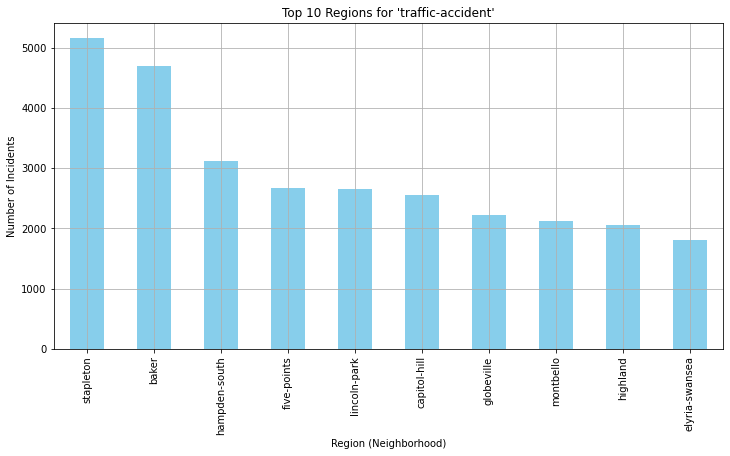

Top 10 Regions for 'traffic-accident':
stapleton         5151
baker             4690
hampden-south     3124
five-points       2673
lincoln-park      2660
capitol-hill      2558
globeville        2221
montbello         2124
highland          2060
elyria-swansea    1807
Name: NEIGHBORHOOD_ID, dtype: int64


In [2]:
# 특정 사건 유형 분석 (예: 'traffic-accident')
specific_event = 'traffic-accident'

# 특정 사건 필터링
specific_event_data = df[df['OFFENSE_TYPE_ID'] == specific_event]

# 지역별 사건 발생 건수 집계
if 'NEIGHBORHOOD_ID' in specific_event_data.columns:
    region_counts = specific_event_data['NEIGHBORHOOD_ID'].value_counts()

    # 상위 10개 지역 시각화
    plt.figure(figsize=(12, 6))
    region_counts.head(10).plot(kind='bar', color='skyblue')
    plt.title(f"Top 10 Regions for '{specific_event}'")
    plt.xlabel('Region (Neighborhood)')
    plt.ylabel('Number of Incidents')
    plt.grid(True)
    plt.show()

    print(f"Top 10 Regions for '{specific_event}':")
    print(region_counts.head(10))
else:
    print("Error: 'NEIGHBORHOOD_ID' column not found in the dataset.")

## 위도와 경도를 기반으로 특정 사건 발생 위치 확인

In [4]:
# 중복된 인덱스 제거
specific_event_data = specific_event_data[~specific_event_data.index.duplicated(keep='first')]

# 중복된 컬럼 제거 (필요한 경우)
specific_event_data = specific_event_data.loc[:, ~specific_event_data.columns.duplicated()]

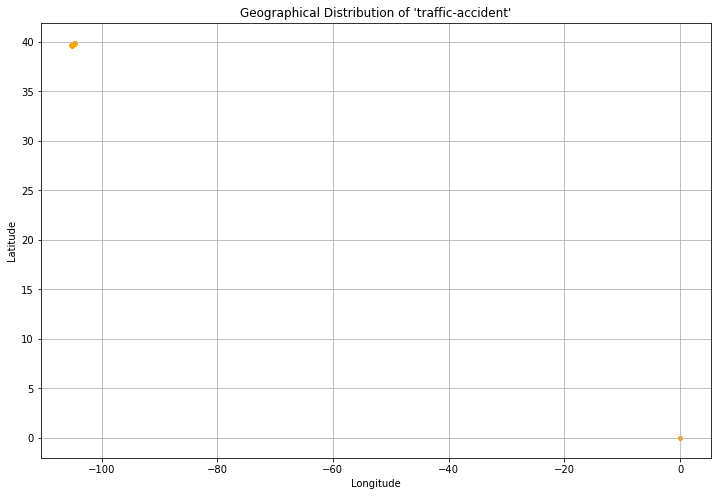

ValueError: Contour levels must be increasing

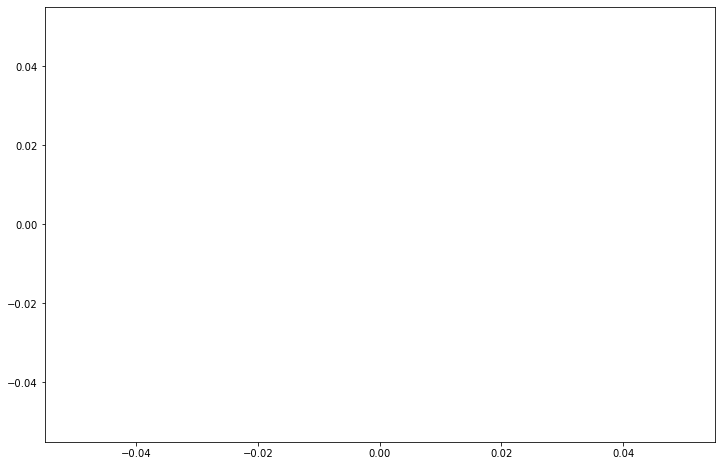

In [5]:
import seaborn as sns

# 위도/경도 컬럼 확인
if 'GEO_LAT' in specific_event_data.columns and 'GEO_LON' in specific_event_data.columns:
    # 결측값 제거
    specific_event_data = specific_event_data.dropna(subset=['GEO_LAT', 'GEO_LON'])

    # 1. 산점도 시각화
    plt.figure(figsize=(12, 8))
    plt.scatter(specific_event_data['GEO_LON'], specific_event_data['GEO_LAT'], alpha=0.5, c='orange', s=10)
    plt.title(f"Geographical Distribution of '{specific_event}'")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()

    # 2. 히트맵 시각화
    plt.figure(figsize=(12, 8))
    sns.kdeplot(
        x=specific_event_data['GEO_LON'], 
        y=specific_event_data['GEO_LAT'], 
        cmap='Reds', fill=True, alpha=0.7
    )
    plt.title(f"Heatmap of '{specific_event}' Incidents")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()
else:
    print("Error: Latitude and/or Longitude columns not found in the dataset.")